# Fourier Analysis and Spectral Theory

This notebook follows **Chapter 6, Spectral Theory**, of Borde & Bronstein, *Mathematical Foundations of Geometric Deep Learning*, with particular emphasis on §6.2, **Fourier analysis**.

The main theme is:

$$
\boxed{\text{finite-dimensional spectral decomposition}
\;\longrightarrow\;
\text{Hilbert-space spectral decomposition}
\;\longrightarrow\;
\text{Fourier analysis}}
$$

We will deliberately move back and forth between finite-dimensional linear algebra and infinite-dimensional function spaces.

We will also use examples motivated by G. F. Simmons, *Differential Equations with Applications and Historical Notes*, especially the vibrating-string example. Simmons' presentation is useful because it makes the connection

$$
\text{eigenvalue problem}
\;\longrightarrow\;
\text{orthogonal eigenfunctions}
\;\longrightarrow\;
\text{Fourier coefficients}
\;\longrightarrow\;
\text{solution of a PDE}
$$

very concrete.

Throughout the notebook:

- examples are accompanied by non-examples whenever useful;
- code is used when computation genuinely illuminates the mathematics;
- finite-dimensional analogies are made explicit;
- the final goal is to understand why spectral methods appear naturally in Geometric Deep Learning.


## 1. From finite-dimensional eigenvectors to infinite-dimensional eigenfunctions

In ordinary linear algebra, an eigenvector of a linear map

$$
A:V\to V
$$

is a nonzero vector satisfying

$$
Av=\lambda v.
$$

If $A$ is a symmetric matrix, we can choose an orthonormal eigenbasis

$$
v_1,\ldots,v_n,
$$

and then every vector $u\in\mathbb R^n$ has the decomposition

$$
u=\sum_{i=1}^n \langle u,v_i\rangle v_i.
$$

*This is already a finite-dimensional Fourier expansion.*

The key change in functional analysis is that the vectors can themselves be **functions**. In a Hilbert space such as $L^2([a,b])$, an eigenfunction satisfies

$$
Af=\lambda f.
$$

When an orthonormal eigenbasis exists, the same formula becomes an infinite series:

$$
f=\sum_{n=1}^{\infty}\langle f,\phi_n\rangle\phi_n.
$$

The coefficients

$$
\widehat f_n=\langle f,\phi_n\rangle
$$

are Fourier coefficients with respect to the basis $\{\phi_n\}$.


### Finite-dimensional example: a symmetric matrix

Consider

$$
A=
\begin{pmatrix}
2&1\\
1&2
\end{pmatrix}.
$$

Because $A$ is symmetric, it has an orthonormal eigenbasis. The two eigenvectors point along the directions

$$
(1,1),\qquad (1,-1),
$$

with eigenvalues $3$ and $1$.

So $A$ acts independently on these two special directions:

$$
A v_1=3v_1,\qquad A v_2=v_2.
$$

This is exactly what we want from a spectral decomposition: instead of understanding $A$ on arbitrary vectors, we understand its action on its fundamental modes.


In [2]:
# try this code in a CAS
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[2.0, 1.0],
              [1.0, 2.0]])

eigenvalues, eigenvectors = np.linalg.eigh(A)

print("Eigenvalues:", eigenvalues)
print("Orthonormal eigenvectors (columns):")
print(eigenvectors)

# Verify A v_i = lambda_i v_i
for i in range(2):
    lhs = A @ eigenvectors[:, i]
    rhs = eigenvalues[i] * eigenvectors[:, i]
    print(f"Mode {i}: error =", np.linalg.norm(lhs - rhs))


Eigenvalues: [1. 3.]
Orthonormal eigenvectors (columns):
[[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]
Mode 0: error = 0.0
Mode 1: error = 0.0


### Example: spectral coordinates

If

$$
u=c_1v_1+c_2v_2,
$$

then the coefficients are obtained by projection:

$$
c_i=\langle u,v_i\rangle.
$$

Thus there are two operations:

1. **analysis:** project onto the basis to obtain coefficients;
2. **synthesis:** combine the basis vectors using those coefficients.

*Fourier analysis is the infinite-dimensional version of exactly this procedure.*


In [3]:
u = np.array([3.0, 1.0])

coefficients = eigenvectors.T @ u
reconstruction = eigenvectors @ coefficients

print("u =", u)
print("Spectral coefficients =", coefficients)
print("Reconstruction =", reconstruction)


u = [3. 1.]
Spectral coefficients = [-1.41421356  2.82842712]
Reconstruction = [3. 1.]


## 2. What changes in infinite dimensions?

In Chapter 5 we treated spaces such as

$$
L^2([-\pi,\pi])
$$

as Hilbert spaces. The inner product is

$$
\langle f,g\rangle
=
\frac{1}{2\pi}
\int_{-\pi}^{\pi}
f(x)\overline{g(x)}\,dx.
$$

The normalization factor is conventional; changing the convention changes the coefficients but not the underlying decomposition.

An eigenfunction of an operator $A$ satisfies

$$
A\phi=\lambda\phi.
$$

The analogy is therefore:

| Finite-dimensional | Infinite-dimensional |
|---|---|
| vector $v$ | function $\phi(x)$ |
| matrix $A$ | operator $A$ |
| eigenvector $v$ | eigenfunction $\phi$ |
| dot product | Hilbert-space inner product |
| eigenbasis | orthonormal basis of functions |
| coordinate $v_i^\top u$ | Fourier coefficient $\langle f,\phi_i\rangle$ |
| matrix diagonalization | spectral decomposition |

This analogy is the central organizing principle of this notebook.


## 3. The Laplacian as a source of Fourier modes

A particularly important operator is the one-dimensional Laplacian.

On an interval, consider the Dirichlet eigenvalue problem

$$
-\frac{d^2u}{dx^2}=\lambda u,
\qquad
u(0)=u(\pi)=0.
$$

For nonzero solutions, the eigenvalues are

$$
\lambda_n=n^2,
\qquad n=1,2,\ldots,
$$

and the corresponding eigenfunctions are

$$
\phi_n(x)=\sqrt{\frac{2}{\pi}}\sin(nx).
$$

The normalization makes

$$
\langle \phi_m,\phi_n\rangle=\delta_{mn}.
$$

So the familiar sine functions are not merely convenient trigonometric functions: they are **eigenfunctions of the Laplacian**.

This is one of the most important ideas for GDL.


### Why are the eigenfunctions orthogonal?

Suppose

$$
-\phi_n''=\lambda_n\phi_n,
\qquad
-\phi_m''=\lambda_m\phi_m.
$$

Multiply the first equation by $\phi_m$, the second by $\phi_n$, and subtract:

$$
\phi_m\phi_n''-\phi_n\phi_m''
=
(\lambda_n-\lambda_m)\phi_m\phi_n.
$$

Integrating by parts gives

$$
\left[
\phi_n'\phi_m-\phi_m'\phi_n
\right]_0^\pi
=
(\lambda_n-\lambda_m)
\int_0^\pi \phi_m\phi_n\,dx.
$$

The Dirichlet boundary conditions make the boundary term vanish. Therefore, when

$$
\lambda_m\neq\lambda_n,
$$

we obtain

$$
\int_0^\pi \phi_m(x)\phi_n(x)\,dx=0.
$$

*This is the infinite-dimensional analogue of the familiar fact that eigenvectors of a symmetric matrix belonging to distinct eigenvalues are orthogonal.*


In [5]:
# Numerically verify orthogonality of several normalized sine eigenfunctions.
from scipy.integrate import trapezoid
x = np.linspace(0, np.pi, 5000)

def phi(n, x):
    return np.sqrt(2 / np.pi) * np.sin(n * x)

N = 5
G = np.zeros((N, N))

for m in range(1, N + 1):
    for n in range(1, N + 1):
        G[m - 1, n - 1] = trapezoid(phi(m, x) * phi(n, x), x)

print(np.round(G, 5))


[[ 1. -0.  0.  0.  0.]
 [-0.  1. -0.  0.  0.]
 [ 0. -0.  1.  0. -0.]
 [ 0.  0.  0.  1.  0.]
 [ 0.  0. -0.  0.  1.]]


### Example and non-example: boundary conditions matter

**Example.** The functions

$$
\sin(nx)
$$

are eigenfunctions of the Dirichlet problem on $[0,\pi]$ because they satisfy both

$$
-\phi_n''=n^2\phi_n
$$

and

$$
\phi_n(0)=\phi_n(\pi)=0.
$$

**Non-example.** The constant function

$$
u(x)=1
$$

is not an eigenfunction of this Dirichlet problem. Although

$$
-u''=0,
$$

it does not satisfy the boundary conditions $u(0)=u(\pi)=0$.

This illustrates an important point: **an eigenfunction problem includes both the differential operator and its domain/boundary conditions.**


## 4. Different boundary conditions produce different Fourier bases

The Laplacian does not have a single universal eigenbasis independent of context.

For the same differential operator, different boundary conditions produce different families.

### Dirichlet boundary conditions

$$
u(0)=u(\pi)=0
$$

give

$$
\sin(nx),\qquad \lambda_n=n^2.
$$

### Neumann boundary conditions

$$
u'(0)=u'(\pi)=0
$$

give

$$
1,\quad \cos(nx),\qquad \lambda_0=0,\quad \lambda_n=n^2.
$$

### Periodic boundary conditions

On a circle,

$$
u(-\pi)=u(\pi),
\qquad
u'(-\pi)=u'(\pi),
$$

the natural eigenfunctions are

$$
e^{inx},\qquad n\in\mathbb Z,
$$

with

$$
-\frac{d^2}{dx^2}e^{inx}=n^2e^{inx}.
$$

*Thus sine, cosine, and complex Fourier bases are all spectral bases arising from closely related eigenvalue problems.*


## 5. Fourier sine series: Simmons' vibrating-string example

Simmons uses the vibrating string to motivate Fourier series.

For a string fixed at both endpoints, separation of variables in the wave equation leads to the spatial eigenvalue problem

$$
u''+\lambda u=0,
\qquad
u(0)=u(\pi)=0.
$$

The allowed modes are

$$
u_n(x)=\sin(nx),
$$

and a formal solution is a sum of these normal modes.

The initial displacement $f(x)$ must therefore be expanded as

$$
f(x)=\sum_{n=1}^{\infty}a_n\sin(nx).
$$

Orthogonality gives

$$
a_n
=
\frac{2}{\pi}
\int_0^\pi f(x)\sin(nx)\,dx.
$$

The important conceptual step is not the integration itself. It is the realization that **the eigenfunctions of the physical operator provide the coordinate system in which the problem becomes simple**.

Simmons emphasizes that the original derivation is initially formal: questions of convergence and term-by-term differentiation require separate analysis. This is an important lesson in spectral methods as well.


### Worked example: $f(x)=x(\pi-x)$

Consider

$$
f(x)=x(\pi-x),
\qquad 0\le x\le\pi.
$$

It satisfies the Dirichlet boundary conditions, so a sine expansion is natural:

$$
f(x)=\sum_{n=1}^{\infty}a_n\sin(nx).
$$

The coefficients are

$$
a_n
=
\frac{2}{\pi}
\int_0^\pi x(\pi-x)\sin(nx)\,dx.
$$

The first few coefficients already give useful approximations. We can compute them numerically and visualize the partial sums.


In [6]:
def sine_coefficients(f, N, x):
    coefficients = []
    for n in range(1, N + 1):
        integrand = f(x) * np.sin(n * x)
        a_n = (2 / np.pi) * trapezoid(integrand, x)
        coefficients.append(a_n)
    return np.array(coefficients)

f = lambda x: x * (np.pi - x)

N = 20
a = sine_coefficients(f, N, x)

print("First 10 sine coefficients:")
print(np.round(a[:10], 6))


First 10 sine coefficients:
[2.546479 0.       0.094314 0.       0.020372 0.       0.007424 0.
 0.003493 0.      ]


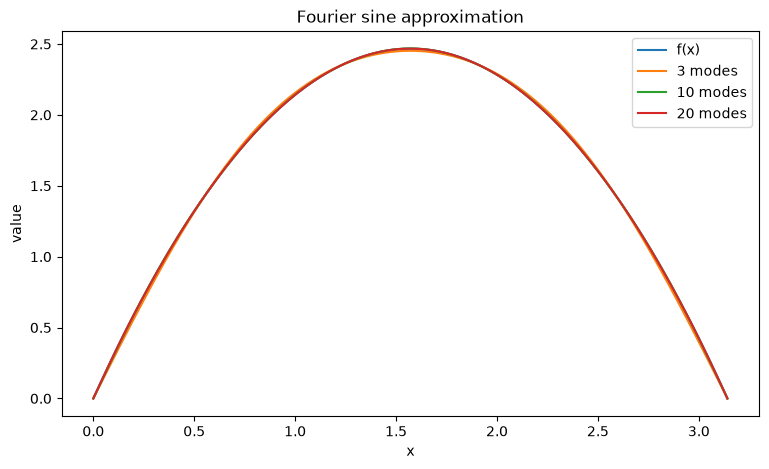

In [7]:
def sine_partial_sum(a, x):
    values = np.zeros_like(x)
    for n, a_n in enumerate(a, start=1):
        values += a_n * np.sin(n * x)
    return values

plt.figure(figsize=(9, 5))
plt.plot(x, f(x), label="f(x)")
plt.plot(x, sine_partial_sum(a[:3], x), label="3 modes")
plt.plot(x, sine_partial_sum(a[:10], x), label="10 modes")
plt.plot(x, sine_partial_sum(a[:20], x), label="20 modes")
plt.xlabel("x")
plt.ylabel("value")
plt.title("Fourier sine approximation")
plt.legend()
plt.show()


### What did the Fourier expansion accomplish?

In the original coordinate description, $f(x)=x(\pi-x)$ is just a curved function.

In spectral coordinates it becomes the sequence

$$
(a_1,a_2,a_3,\ldots).
$$

The function has been replaced by its amplitudes in the natural modes of the operator.

This is exactly analogous to replacing

$$
u\in\mathbb R^n
$$

by its coordinates

$$
(\langle u,v_1\rangle,\ldots,\langle u,v_n\rangle)
$$

in an eigenbasis.


## 6. Fourier series on the circle

For periodic functions, the natural Hilbert space is

$$
L^2(S^1),
$$

which we may represent using functions on $[-\pi,\pi]$ with periodic identification.

The complex exponential modes are

$$
e_n(x)=e^{inx},
\qquad n\in\mathbb Z.
$$

With the normalized inner product

$$
\langle f,g\rangle
=
\frac{1}{2\pi}
\int_{-\pi}^{\pi}
f(x)\overline{g(x)}\,dx,
$$

we have

$$
\langle e_n,e_m\rangle=\delta_{nm}.
$$

Hence

$$
f(x)
=
\sum_{n\in\mathbb Z}
\widehat f_n e^{inx},
$$

where

$$
\widehat f_n
=
\frac{1}{2\pi}
\int_{-\pi}^{\pi}
f(x)e^{-inx}\,dx.
$$

This is the classical Fourier series.


In [8]:
# Numerical orthogonality check for complex Fourier modes.

x_circle = np.linspace(-np.pi, np.pi, 10001)

def fourier_mode(n, x):
    return np.exp(1j * n * x)

for n, m in [(0, 0), (1, 1), (1, 2), (-2, 2)]:
    inner = (1 / (2 * np.pi)) * trapezoid(
        fourier_mode(n, x_circle) * np.conjugate(fourier_mode(m, x_circle)),
        x_circle
    )
    print(f"<e_{n}, e_{m}> =", np.round(inner, 8))


<e_0, e_0> = (1+0j)
<e_1, e_1> = (1-0j)
<e_1, e_2> = 0j
<e_-2, e_2> = (-0-0j)


### Real versus complex Fourier bases

The complex basis

$$
\{e^{inx}\}_{n\in\mathbb Z}
$$

and the real basis

$$
\{1,\cos(nx),\sin(nx)\}_{n\ge1}
$$

encode the same information.

Euler's identity

$$
e^{inx}=\cos(nx)+i\sin(nx)
$$

shows why.

For real-valued functions, one often writes

$$
f(x)
=
\frac{a_0}{2}
+
\sum_{n=1}^{\infty}
\left(
a_n\cos(nx)+b_n\sin(nx)
\right).
$$

The complex notation is usually more convenient for spectral calculations because the derivative and Laplacian act diagonally:

$$
\frac{d}{dx}e^{inx}=in e^{inx},
$$

and

$$
-\frac{d^2}{dx^2}e^{inx}=n^2e^{inx}.
$$


## 7. Example: a square wave and the Gibbs phenomenon

Consider the $2\pi$-periodic square wave

$$
f(x)=
\begin{cases}
1,&0<x<\pi,\\
-1,&-\pi<x<0.
\end{cases}
$$

Its Fourier series contains only odd sine modes:

$$
f(x)
\sim
\frac{4}{\pi}
\left(
\sin x+\frac{1}{3}\sin 3x+\frac{1}{5}\sin 5x+\cdots
\right).
$$

This example is useful because it shows that Fourier convergence is not the same thing as pointwise convergence of partial sums to a discontinuous function at every point.

At the jump, the Fourier series converges to the midpoint of the left and right limits, namely $0$. Near the jump, finite partial sums exhibit the familiar overshoot known as the **Gibbs phenomenon.**


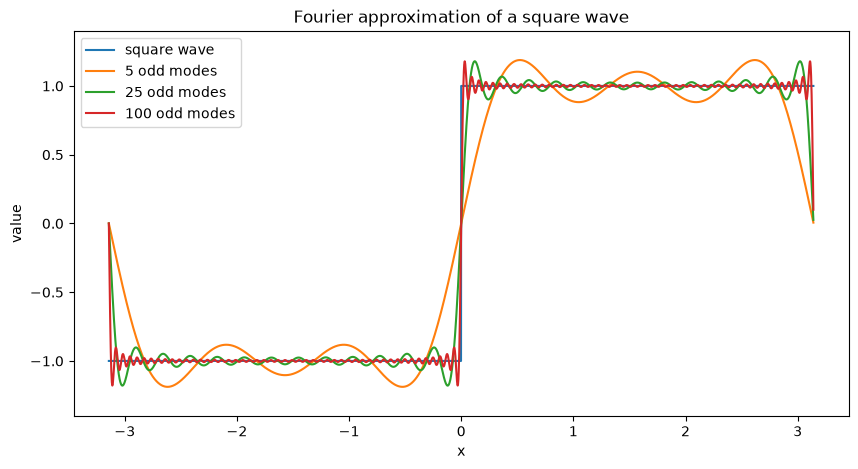

In [9]:
x_sq = np.linspace(-np.pi, np.pi, 4000, endpoint=False)

square_wave = np.where(x_sq >= 0, 1.0, -1.0)

def square_partial_sum(x, N):
    result = np.zeros_like(x)
    for k in range(1, N + 1, 2):
        result += np.sin(k * x) / k
    return (4 / np.pi) * result

plt.figure(figsize=(10, 5))
plt.plot(x_sq, square_wave, label="square wave")
plt.plot(x_sq, square_partial_sum(x_sq, 5), label="5 odd modes")
plt.plot(x_sq, square_partial_sum(x_sq, 25), label="25 odd modes")
plt.plot(x_sq, square_partial_sum(x_sq, 100), label="100 odd modes")
plt.ylim(-1.4, 1.4)
plt.xlabel("x")
plt.ylabel("value")
plt.title("Fourier approximation of a square wave")
plt.legend()
plt.show()


### Example and non-example: what does Fourier convergence mean?

**Example.** For a sufficiently regular periodic function, Fourier partial sums can converge pointwise to the function and converge in $L^2$.

**Non-example.** At a jump discontinuity, the ordinary Fourier series does not converge to either one-sided value. Under the usual hypotheses it converges to the midpoint of the jump.

This distinction matters because there are several different notions of convergence:

$$
\text{pointwise},\qquad
\text{uniform},\qquad
L^2\text{ convergence},\qquad
\text{almost-everywhere convergence}.
$$

The functional-analytic setting tells us which notion is natural for the problem at hand.


## 8. Parseval's identity: geometry survives the change of coordinates

One of the deepest reasons Fourier analysis is useful is that it preserves the Hilbert-space geometry.

For an orthonormal basis $\{\phi_n\}$,

$$
f=\sum_n \widehat f_n\phi_n,
\qquad
\widehat f_n=\langle f,\phi_n\rangle.
$$

Parseval's identity says

$$
\|f\|^2
=
\sum_n|\widehat f_n|^2.
$$

More generally, if $f=\sum_n \widehat f_n\phi_n$ and $g=\sum_n \widehat g_n\phi_n$, then

$$
\langle f,g\rangle
=
\sum_n
\widehat f_n\overline{\widehat g_n}.
$$

Thus the Fourier transform is not merely a representation of a function. It is an isometric change of coordinates between the function and its spectral coefficients.

This is the infinite-dimensional analogue of

$$
\|u\|^2
=
\sum_i|\langle u,v_i\rangle|^2
$$

for an orthonormal basis in $\mathbb R^n$.


In [10]:
# Numerical Parseval check for a smooth periodic function.

x = np.linspace(-np.pi, np.pi, 20001)
f_periodic = np.exp(np.cos(x)) + 0.3 * np.sin(3 * x)

# Compute coefficients directly by numerical integration.
N = 40
coeffs = np.array([
    (1 / (2 * np.pi)) *
    trapezoid(f_periodic * np.exp(-1j * n * x), x)
    for n in range(-N, N + 1)
])

norm_f_squared = (1 / (2 * np.pi)) * trapezoid(np.abs(f_periodic) ** 2, x)
spectral_energy = np.sum(np.abs(coeffs) ** 2)

print("Function energy:", norm_f_squared)
print("Energy in first", 2 * N + 1, "modes:", spectral_energy)
print("Difference:", norm_f_squared - spectral_energy)


Function energy: 2.3245853023360676
Energy in first 81 modes: 2.3245853023360676
Difference: 0.0


## 9. The Fourier transform on $\mathbb R$

Fourier series arise naturally when the domain is periodic, so the frequencies are discrete:

$$
n\in\mathbb Z.
$$

On the real line, the frequency becomes continuous:

$$
\omega\in\mathbb R.
$$

Schematically,

$$
f(x)
=
\int_{-\infty}^{\infty}
\widehat f(\omega)e^{i\omega x}\,d\omega.
$$

The Fourier transform is, up to normalization convention,

$$
\widehat f(\omega)
=
\int_{-\infty}^{\infty}
f(x)e^{-i\omega x}\,dx.
$$

The distinction is therefore:

$$
\boxed{
\begin{array}{c}
\text{periodic domain}\\
\Downarrow\\
\text{discrete spectrum}
\end{array}}
\qquad
\boxed{
\begin{array}{c}
\text{non-periodic line}\\
\Downarrow\\
\text{continuous spectrum}
\end{array}}
$$

This is the same idea expressed in two different spectral settings.


### Example: a Gaussian

The Gaussian is especially useful because its Fourier transform is another Gaussian.

We can see the basic phenomenon numerically using the FFT. The precise normalization depends on the Fourier-transform convention, so here the purpose is to visualize the reciprocal relationship between localization in physical space and frequency space.


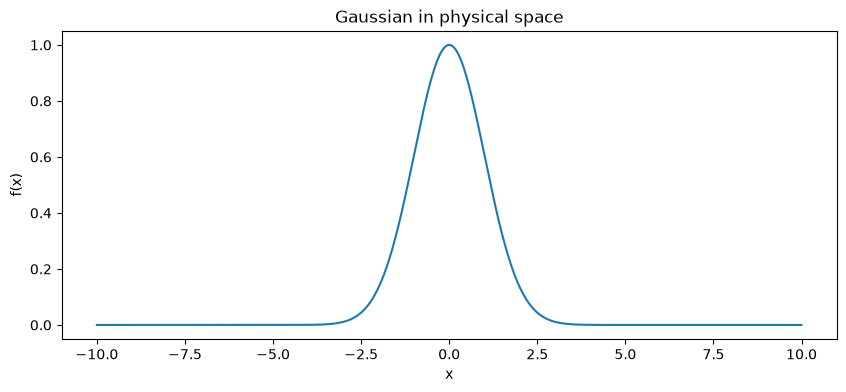

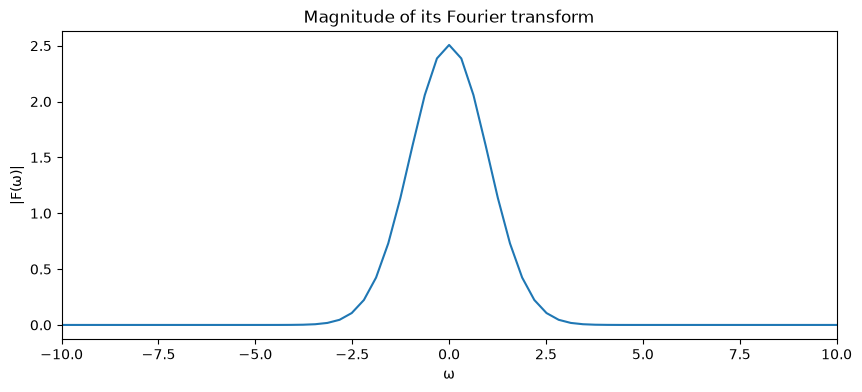

In [11]:
from scipy.fft import fft, fftfreq, fftshift

# Sample a Gaussian on a large interval.
L = 20.0
N = 4096
x_fft = np.linspace(-L / 2, L / 2, N, endpoint=False)
dx = x_fft[1] - x_fft[0]

gaussian = np.exp(-x_fft**2 / 2)

# FFT and corresponding angular frequencies.
F = fftshift(fft(gaussian)) * dx
freq = fftshift(fftfreq(N, d=dx)) * 2 * np.pi

plt.figure(figsize=(10, 4))
plt.plot(x_fft, gaussian)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gaussian in physical space")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(freq, np.abs(F))
plt.xlim(-10, 10)
plt.xlabel("ω")
plt.ylabel("|F(ω)|")
plt.title("Magnitude of its Fourier transform")
plt.show()


## 10. The discrete Fourier transform: a finite-dimensional Fourier theory

There is an especially illuminating finite-dimensional analogy.

Consider the cyclic shift operator on $\mathbb C^N$:

$$
(Su)_j=u_{j-1},
$$

with indices interpreted modulo $N$.

The eigenvectors of $S$ are the discrete Fourier modes

$$
v_k(j)=\frac{1}{\sqrt N}e^{2\pi i kj/N}.
$$

Thus the discrete Fourier transform diagonalizes the shift.

This gives a powerful dictionary:

| Finite cyclic setting | Continuous periodic setting |
|---|---|
| vector $u_j$ | function $f(x)$ |
| cyclic shift | translation |
| DFT modes | $e^{inx}$ |
| DFT coefficients | Fourier coefficients |
| eigenvalues of shift | frequency phases |
| discrete Laplacian | continuous Laplacian |

This is one reason Fourier analysis is so central in signal processing and in the study of convolution.


In [12]:
# Construct the cyclic shift matrix and verify that DFT modes are eigenvectors.

N = 8
S = np.zeros((N, N), dtype=complex)

for j in range(N):
    S[j, (j - 1) % N] = 1.0

j = np.arange(N)
omega = np.exp(2j * np.pi / N)

for k in range(N):
    v = omega ** (k * j)
    v = v / np.linalg.norm(v)

    Sv = S @ v
    # The eigenvalue depends on the precise shift convention.
    eigenvalue = np.vdot(v, Sv)

    error = np.linalg.norm(Sv - eigenvalue * v)
    print(f"k={k}: eigenvalue={eigenvalue:.3f}, error={error:.2e}")


k=0: eigenvalue=1.000+0.000j, error=1.57e-16
k=1: eigenvalue=0.707-0.707j, error=3.77e-16
k=2: eigenvalue=-0.000-1.000j, error=6.08e-16
k=3: eigenvalue=-0.707-0.707j, error=8.71e-16
k=4: eigenvalue=-1.000+0.000j, error=1.19e-15
k=5: eigenvalue=-0.707+0.707j, error=1.50e-15
k=6: eigenvalue=0.000+1.000j, error=1.77e-15
k=7: eigenvalue=0.707+0.707j, error=2.06e-15


### Why this matters

A translation-invariant operator becomes multiplication in Fourier space.

For example, if

$$
T f = k*f
$$

is convolution by a kernel $k$, then formally

$$
\widehat{Tf}(\omega)
=
\widehat k(\omega)\widehat f(\omega).
$$

So convolution becomes diagonal in the Fourier basis.

This is the spectral origin of the familiar idea of a **frequency filter**: the operator acts independently on each Fourier mode.


## 11. The heat equation: spectral decomposition turns dynamics into scalar equations

Simmons' vibrating-string example illustrates oscillatory modes. The heat equation gives a complementary example.

On the circle,

$$
\frac{\partial f}{\partial t}
=
\frac{\partial^2 f}{\partial x^2}.
$$

For a single Fourier mode

$$
f(x,t)=e^{inx}T(t),
$$

we have

$$
\frac{\partial^2}{\partial x^2}e^{inx}
=
-n^2e^{inx}.
$$

Therefore,

$$
T'(t)=-n^2T(t),
$$

whose solution is

$$
T(t)=e^{-n^2t}.
$$

Hence each mode evolves independently:

$$
e^{inx}
\quad\longmapsto\quad
e^{-n^2t}e^{inx}.
$$

The higher the frequency $|n|$, the faster the mode decays.

This gives a clean interpretation of heat flow as a **low-pass spectral filter**.


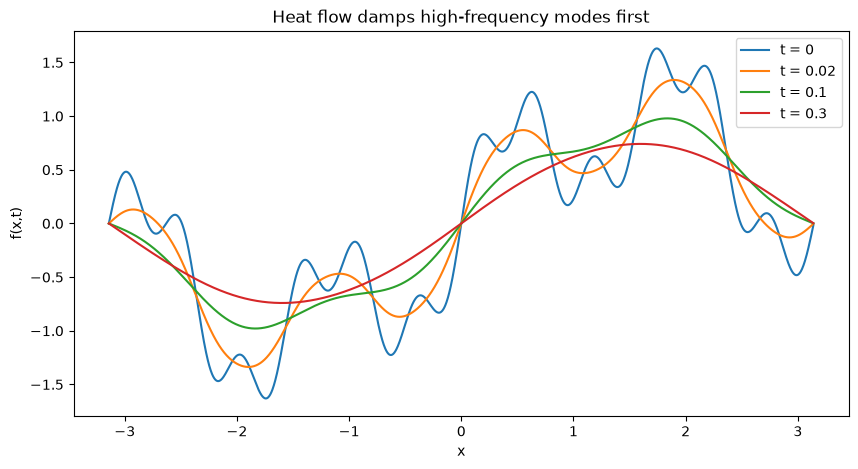

In [13]:
# Heat equation on the circle: start with a mixture of frequencies.

x = np.linspace(-np.pi, np.pi, 2000, endpoint=False)

initial = (
    np.sin(x)
    + 0.6 * np.sin(4 * x)
    + 0.3 * np.sin(12 * x)
)

def heat_solution(x, t):
    return (
        np.exp(-1**2 * t) * np.sin(x)
        + 0.6 * np.exp(-4**2 * t) * np.sin(4 * x)
        + 0.3 * np.exp(-12**2 * t) * np.sin(12 * x)
    )

plt.figure(figsize=(10, 5))
plt.plot(x, initial, label="t = 0")
plt.plot(x, heat_solution(x, 0.02), label="t = 0.02")
plt.plot(x, heat_solution(x, 0.1), label="t = 0.1")
plt.plot(x, heat_solution(x, 0.3), label="t = 0.3")
plt.xlabel("x")
plt.ylabel("f(x,t)")
plt.title("Heat flow damps high-frequency modes first")
plt.legend()
plt.show()


## 12. Spectral filtering

Suppose

$$
f=\sum_n\widehat f_n\phi_n
$$

in an eigenbasis of an operator $L$:

$$
L\phi_n=\lambda_n\phi_n.
$$

A spectral filter is an operator of the form

$$
h(L)\phi_n=h(\lambda_n)\phi_n.
$$

Therefore,

$$
h(L)f
=
\sum_n
h(\lambda_n)\widehat f_n\phi_n.
$$

The operator acts by multiplying each spectral coefficient by a scalar.

Examples:

- **low-pass filtering:** preserve small $\lambda_n$ and suppress large $\lambda_n$;
- **high-pass filtering:** suppress small $\lambda_n$ and preserve large $\lambda_n$;
- **heat diffusion:** $h(\lambda)=e^{-t\lambda}$;
- **spectral sharpening:** choose a function $h$ that amplifies selected frequencies.

*This formulation will become particularly important once we reach graph Laplacians.*


## 13. Not every operator has a nice eigenbasis

It is tempting to think that every matrix or operator can be diagonalized. This is false.

### Finite-dimensional non-example

Consider

$$
A=
\begin{pmatrix}
1&1\\
0&1
\end{pmatrix}.
$$

Its only eigenvalue is $1$, and its eigenspace is one-dimensional. Therefore there is no basis of eigenvectors.

So we cannot write

$$
A=V\Lambda V^{-1}
$$

with $V$ invertible and $\Lambda$ diagonal.

This is why the hypotheses of spectral theorems matter.

For self-adjoint operators, the situation is dramatically better: eigenvalues are real and eigenvectors corresponding to distinct eigenvalues are orthogonal; in the appropriate compact/infinite-dimensional setting, one obtains an orthonormal eigenbasis.

This is one reason the Laplacian is so important.


In [14]:
A_bad = np.array([[1.0, 1.0],
                    [0.0, 1.0]])

eigenvalues_bad, eigenvectors_bad = np.linalg.eig(A_bad)

print("Eigenvalues:", eigenvalues_bad)
print("Eigenvector matrix:")
print(eigenvectors_bad)
print("Rank of eigenvector matrix:", np.linalg.matrix_rank(eigenvectors_bad))


Eigenvalues: [1. 1.]
Eigenvector matrix:
[[ 1.00000000e+00 -1.00000000e+00]
 [ 0.00000000e+00  2.22044605e-16]]
Rank of eigenvector matrix: 1


### Another non-example: an arbitrary function is not automatically a Fourier mode

For the Laplacian on the circle,

$$
-\frac{d^2}{dx^2}e^{inx}=n^2e^{inx}.
$$

But a generic function such as

$$
f(x)=x^2
$$

is not an eigenfunction:

$$
-f''(x)=-2,
$$

which is not a scalar multiple of $x^2$.

Instead, $x^2$ must be **expanded in the eigenbasis**.

This distinction is fundamental:

$$
\boxed{
\text{eigenfunction} \neq \text{arbitrary function}
}
$$

but, when the eigenfunctions form a complete basis,

$$
\boxed{
\text{arbitrary function}
=
\text{sum of eigenfunctions}.
}
$$


## 14. Fourier analysis as diagonalization

We can now summarize the central picture.

Suppose

$$
L\phi_n=\lambda_n\phi_n
$$

and

$$
f=\sum_n\widehat f_n\phi_n.
$$

Then

$$
Lf
=
\sum_n
\lambda_n\widehat f_n\phi_n.
$$

So in spectral coordinates, $L$ is simply multiplication by the eigenvalue:

$$
\boxed{
\widehat{Lf}_n
=
\lambda_n\widehat f_n.
}
$$

Compare this with finite-dimensional diagonalization:

$$
A=V\Lambda V^{-1}.
$$

The Fourier transform plays the role of the change of basis:

$$
f
\overset{\mathcal F}{\longmapsto}
\widehat f,
$$

while the operator becomes diagonal:

$$
\mathcal F L\mathcal F^{-1}
=
\Lambda.
$$

This is perhaps the most useful mental model for spectral theory.


## 15. A finite/infinite-dimensional dictionary

Here is the dictionary we will carry into GDL.

$$
\begin{array}{c|c}
\text{Linear algebra} & \text{Fourier / functional analysis}\\
\hline
\mathbb R^n & L^2(M)\\
\text{vector} & \text{function / signal}\\
\text{matrix} & \text{operator}\\
\text{eigenvector} & \text{eigenfunction}\\
\text{orthonormal eigenbasis} & \text{orthonormal basis of modes}\\
V^\top u & \langle f,\phi_n\rangle\\
V\Lambda V^\top & \text{spectral decomposition}\\
\text{coordinate} & \text{Fourier coefficient}\\
\text{diagonal multiplication} & \text{spectral filtering}
\end{array}
$$

The passage to GDL will replace the ordinary Euclidean domain by a geometric domain such as a graph or manifold.

The basic question remains the same:

> **What are the natural modes of the operator that encodes the geometry?**


## 16. Connection to Geometric Deep Learning

The importance of Fourier analysis for GDL is now visible.

On a regular one-dimensional domain, the Laplacian has Fourier eigenfunctions:

$$
-\Delta e^{inx}=n^2e^{inx}.
$$

On a graph, the graph Laplacian is a finite matrix:

$$
L=D-A.
$$

Its eigenvectors play the role of Fourier modes.

If

$$
Lu_i=\lambda_i u_i,
$$

then a graph signal $x$ can be decomposed as

$$
x=\sum_i\widehat x_i u_i,
\qquad
\widehat x_i=u_i^\top x.
$$

A graph spectral filter can then be written as

$$
h(L)x
=
\sum_i h(\lambda_i)\widehat x_i u_i.
$$

So the graph Fourier transform is not an arbitrary analogy with ordinary Fourier analysis. It comes from the same spectral principle:

$$
\boxed{
\text{Laplacian eigenvectors}
=
\text{geometry-adapted Fourier modes}.
}
$$

We will develop this explicitly when we reach the graph-theory part of the GDL project.


## 17. A useful conceptual hierarchy

It is useful to keep four levels separate:

### Level 1: basis expansion

$$
f=\sum_n \widehat f_n\phi_n.
$$

### Level 2: operator diagonalization

$$
L\phi_n=\lambda_n\phi_n.
$$

Therefore

$$
\widehat{Lf}_n=\lambda_n\widehat f_n.
$$

### Level 3: spectral filtering

$$
h(L)f
=
\sum_nh(\lambda_n)\widehat f_n\phi_n.
$$

### Level 4: geometric deep learning

Choose an operator whose eigenfunctions encode the geometry, then learn or prescribe a function of its spectrum.

This is the conceptual bridge from classical Fourier analysis to spectral GNNs and related geometric architectures.


## 18. Exercises

### Exercise 1 — finite-dimensional Fourier decomposition

Let

$$
A=
\begin{pmatrix}
3&1\\
1&3
\end{pmatrix}.
$$

1. Find its eigenvalues and orthonormal eigenvectors.
2. Decompose $u=(2,1)$ in the eigenbasis.
3. Compute $Au$ using the spectral decomposition.

---

### Exercise 2 — orthogonality

Show directly that

$$
\int_0^\pi\sin(mx)\sin(nx)\,dx=0
$$

for $m\neq n$.

Then compute the norm of $\sin(nx)$.

---

### Exercise 3 — sine-series coefficients

Find the sine-series coefficients of

$$
f(x)=x
$$

on $[0,\pi]$.

Use the result to numerically compare the first $N$ partial sums with $f(x)$.

---

### Exercise 4 — cosine modes

Solve

$$
-u''=\lambda u,
\qquad
u'(0)=u'(\pi)=0.
$$

Find the eigenvalues and eigenfunctions. Explain why the constant function appears.

---

### Exercise 5 — Fourier and the Laplacian

Verify

$$
-\frac{d^2}{dx^2}e^{inx}=n^2e^{inx}.
$$

Then explain why the Laplacian acts as multiplication by $n^2$ in Fourier space.

---

### Exercise 6 — heat flow

Start with

$$
f(x,0)=\sin(x)+\sin(5x).
$$

Write the solution to the heat equation on the circle and determine which mode dominates as $t\to\infty$.

---

### Exercise 7 — non-example

Find a nonzero function that is not an eigenfunction of the one-dimensional Laplacian. Explain why.

---

### Exercise 8 — spectral filtering

Suppose

$$
L\phi_n=\lambda_n\phi_n.
$$

Show that the heat operator

$$
e^{-tL}
$$

acts as the spectral filter

$$
h(\lambda)=e^{-t\lambda}.
$$

Explain why this suppresses high frequencies.


## 19. Summary

The main ideas of this notebook are:

1. **Eigenvectors provide natural coordinates** in finite-dimensional linear algebra.
2. The same idea extends to **eigenfunctions in Hilbert spaces**.
3. The Laplacian naturally produces frequency modes.
4. Fourier series are expansions in an orthonormal basis of such modes.
5. Fourier coefficients are obtained by projection:

   $$
   \widehat f_n=\langle f,\phi_n\rangle.
   $$

6. Parseval's identity says that the Hilbert-space geometry is preserved:

   $$
   \|f\|^2=\sum_n|\widehat f_n|^2.
   $$

7. In Fourier coordinates, differential operators such as the Laplacian become diagonal.
8. Heat flow becomes a simple mode-by-mode decay process.
9. Spectral filtering acts by multiplying each Fourier coefficient by a function of the eigenvalue.
10. On graphs, Laplacian eigenvectors play the role of Fourier modes.

The key idea to retain is therefore:

$$
\boxed{
\text{Fourier analysis is spectral decomposition adapted to a domain and an operator.}
}
$$

This is the conceptual foundation for the spectral viewpoint in Geometric Deep Learning.


## Appendix
### Convolution as an Operator on a Hilbert Space

Let $H=L^2(\mathbb{R})$ be the Hilbert space of square-integrable signals. Given a filter (or kernel) $\theta$, the convolution operator

$$
T_\theta : H \to H
$$

is defined by

$$
(T_\theta x)(u)
=
(x * \theta)(u)
=
\int_{-\infty}^{\infty}
x(v)\theta(u-v)\,dv.
$$

Thus convolution can be viewed as a **linear operator acting on the Hilbert space of signals**:

$$
T_\theta x = x * \theta.
$$

The convolution operator is linear:

$$
T_\theta(ax+by)
=
aT_\theta x+bT_\theta y.
$$

For suitable functions, convolution is also translation-equivariant. If

$$
(\tau_a x)(u)=x(u-a)
$$

denotes translation by $a$, then

$$
T_\theta(\tau_a x)
=
\tau_a(T_\theta x).
$$

In other words,

$$
T_\theta\tau_a=\tau_aT_\theta.
$$

This commutation relation is important: convolution is precisely the type of linear operation that respects translations.

### Convolution and the Fourier basis

The Fourier modes

$$
\phi_\xi(u)=e^{i\xi u}
$$

are eigenfunctions of every convolution operator (under the usual assumptions). Indeed,

$$
(T_\theta\phi_\xi)(u)
=
\int_{-\infty}^{\infty}
e^{i\xi v}\theta(u-v)\,dv.
$$

Setting $w=u-v$, so that $v=u-w$, gives

$$
\begin{aligned}
(T_\theta\phi_\xi)(u)
&=
\int_{-\infty}^{\infty}
e^{i\xi(u-w)}\theta(w)\,dw\\
&=
e^{i\xi u}
\int_{-\infty}^{\infty}
\theta(w)e^{-i\xi w}\,dw.
\end{aligned}
$$

The integral is the Fourier transform of $\theta$:

$$
\widehat{\theta}(\xi)
=
\int_{-\infty}^{\infty}
\theta(w)e^{-i\xi w}\,dw.
$$

Therefore,

$$
T_\theta\phi_\xi
=
\widehat{\theta}(\xi)\phi_\xi.
$$

Thus the Fourier modes are eigenfunctions of the convolution operator, with eigenvalues given by the Fourier transform of the filter:

$$
\boxed{
T_\theta e^{i\xi u}
=
\widehat{\theta}(\xi)e^{i\xi u}.
}
$$

This is the operator-theoretic reason that the Fourier transform diagonalizes convolution.

If

$$
x(u)
=
\int
\widehat{x}(\xi)e^{i\xi u}\,d\xi,
$$

then

$$
T_\theta x
=
\int
\widehat{\theta}(\xi)\widehat{x}(\xi)
e^{i\xi u}\,d\xi.
$$

Equivalently,

$$
\boxed{
\widehat{x*\theta}(\xi)
=
\widehat{x}(\xi)\widehat{\theta}(\xi).
}
$$

This is the **Convolution Theorem**.

Hence convolution becomes simple multiplication in the Fourier basis:

$$
x
\overset{\mathcal F}{\longmapsto}
\widehat{x},
\qquad
T_\theta
\overset{\mathcal F}{\longmapsto}
\widehat{\theta}(\xi)\cdot.
$$

This is directly analogous to diagonalizing a matrix. If

$$
Av_i=\lambda_i v_i,
$$

then

$$
A
=
V\Lambda V^{-1},
$$

and the action of $A$ in the eigenbasis is simply multiplication by $\lambda_i$.

For convolution,

$$
T_\theta\phi_\xi
=
\widehat{\theta}(\xi)\phi_\xi,
$$

so the Fourier basis plays the role of the eigenbasis and $\widehat{\theta}(\xi)$ plays the role of the eigenvalue.

### Connection to GDL

This observation is fundamental for Geometric Deep Learning. On Euclidean domains, translations determine the relevant symmetry and Fourier modes diagonalize translation-equivariant convolution.

The spectral viewpoint then suggests a generalization:

$$
\boxed{
\text{find an operator encoding the geometry}
\;\longrightarrow\;
\text{find its eigenfunctions}
\;\longrightarrow\;
\text{filter in the spectral domain}.
}
$$

For a graph or manifold, the Laplacian provides a natural geometric operator. Its eigenfunctions play the role of Fourier modes, allowing convolution-like operations to be defined spectrally.

## References

### Primary GDL source

1. H. Sáez de Ocáriz Borde and M. Bronstein, **Mathematical Foundations of Geometric Deep Learning**, arXiv:2508.02723, especially Chapter 6, §§6.1–6.2.  
   https://arxiv.org/abs/2508.02723

### Fourier analysis

2. E. M. Stein and R. Shakarchi, **Fourier Analysis: An Introduction**, Princeton University Press, 2003/2011.  
   A useful companion for Fourier series, convergence, the Fourier transform, and applications.  
   https://press.princeton.edu/books/hardcover/9780691113845/fourier-analysis

3. G. F. Simmons, **Differential Equations with Applications and Historical Notes**, McGraw-Hill.  
   In particular, the discussion of the vibrating string and eigenfunction expansions in Chapter 4, §24. The book gives an especially concrete motivation for Fourier series through separation of variables and boundary-value eigenproblems.

### Functional analysis and spectral theory

4. J. B. Conway, **A Course in Functional Analysis**, Springer.

5. E. Kreyszig, **Introductory Functional Analysis with Applications**, Wiley.

6. W. Rudin, **Functional Analysis**, McGraw-Hill.

### Geometric deep learning

7. M. M. Bronstein, J. Bruna, T. Cohen, and P. Veličković, **Geometric Deep Learning: Grids, Groups, Graphs, Geodesics, and Gauges**, arXiv:2104.13478.  
   https://arxiv.org/abs/2104.13478

### Previous notebook

8. `06_functional_analysis.ipynb` in this repository.

---

### A note on the role of the references

Borde & Bronstein provide the GDL-oriented spectral framework. Simmons is particularly useful for the **eigenfunction-expansion viewpoint arising from differential equations**, while Stein–Shakarchi provides a broader and more systematic treatment of Fourier analysis. The notebook intentionally uses all three viewpoints rather than treating Fourier series as a collection of formulas.
